UNESCO World Heritage Sites


### Step 1: Generate the Data

In [ ]:
import pandas as pd
import numpy as np
import os

# --- Configuration for synthetic data ---
NUM_ROWS = 1200

countries = [
    'France', 'Italy', 'Spain', 'Germany', 'United Kingdom',
    'China', 'India', 'Japan', 'Brazil', 'Mexico',
    'Egypt', 'Australia', 'Canada', 'South Africa', 'Greece'
]

categories_dist = {'Cultural': 940, 'Natural': 220, 'Mixed': 40}
category_list = [k for k, v in categories_dist.items() for _ in range(v)]

regions = [
    'Africa', 'Arab States', 'Asia and the Pacific',
    'Europe and North America', 'Latin America and the Caribbean'
]

# --- Generate data ---
data = {}
data['Name'] = [f'Heritage Site {i+1}' for i in range(NUM_ROWS)]

# Country with multi-country entries (about 50 rows)
country_col = []
for i in range(NUM_ROWS):
    if i < 50:
        country_col.append(f'{np.random.choice(countries)}, {np.random.choice(countries)}')
    else:
        country_col.append(np.random.choice(countries))
data['Country'] = country_col

# Category
data['Category'] = np.random.permutation(category_list).tolist()

# Year
data['Year'] = np.random.randint(1978, 2024, NUM_ROWS) # 2024 exclusive, so up to 2023

# Area (hectares) with 5% NaN
area_col = np.random.uniform(10, 10000, NUM_ROWS)
nan_indices = np.random.choice(NUM_ROWS, size=int(NUM_ROWS * 0.05), replace=False)
area_col[nan_indices] = np.nan
data['Area'] = area_col

# Danger List with 5% 'Yes'
data['Danger'] = np.random.choice(['No', 'Yes'], size=NUM_ROWS, p=[0.95, 0.05])

# Region
data['Region'] = np.random.choice(regions, size=NUM_ROWS)

# Latitude & Longitude
data['Latitude'] = np.random.uniform(-90, 90, NUM_ROWS)
data['Longitude'] = np.random.uniform(-180, 180, NUM_ROWS)

# Create DataFrame
df = pd.DataFrame(data)

# Save to CSV
csv_filename = 'unesco_sites.csv'
df.to_csv(csv_filename, index=False)
print(f"Synthetic dataset saved to {csv_filename}")

# Load it back to confirm
df = pd.read_csv(csv_filename)
print(f"Dataset re-loaded from {csv_filename}. Shape: {df.shape}")

print("\nFirst 5 rows of the generated DataFrame:")
display(df.head())

print("\nDataFrame Info:")
df.info()

Synthetic dataset saved to unesco_sites.csv
Dataset re-loaded from unesco_sites.csv. Shape: (1200, 9)

First 5 rows of the generated DataFrame:


,Name,Country,Category,Year,Area,Danger,Region,Latitude,Longitude
0,Heritage Site 1,"France, Mexico",Cultural,2000,563.318631,No,Asia and the Pacific,17.547346,-108.909695
1,Heritage Site 2,"India, France",Natural,2014,7416.990714,No,Latin America and the Caribbean,58.342888,-66.743892
2,Heritage Site 3,"Brazil, Spain",Natural,1987,9285.820796,Yes,Europe and North America,47.728888,105.134905
3,Heritage Site 4,"Italy, Greece",Cultural,2001,8103.531591,No,Latin America and the Caribbean,70.839293,80.615429
4,Heritage Site 5,"Egypt, France",Cultural,1987,5677.824866,No,Europe and North America,-35.818104,144.111212



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Name       1200 non-null   object 
 1   Country    1200 non-null   object 
 2   Category   1200 non-null   object 
 3   Year       1200 non-null   int64  
 4   Area       1140 non-null   float64
 5   Danger     1200 non-null   object 
 6   Region     1200 non-null   object 
 7   Latitude   1200 non-null   float64
 8   Longitude  1200 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 84.5+ KB


### Step 2: Simple Data Cleaning

In [5]:
df_clean = df.copy()

# 1. Create 'primary_country' column
df_clean['primary_country'] = df_clean['Country'].apply(lambda x: x.split(',')[0].strip())
print(f"'primary_country' column created. First 5 values: {df_clean['primary_country'].head().tolist()}")

# 2. Fill missing values
# We generated NaNs only in 'Area', so let's handle that.
# A simple approach is to fill with the median of the column or by category.
# Filling with median of its category is more robust.
initial_nan_count_area = df_clean['Area'].isnull().sum()
df_clean['Area'] = df_clean.groupby('Category')['Area'].transform(lambda x: x.fillna(x.median()))
final_nan_count_area = df_clean['Area'].isnull().sum()

print(f"\nInitial NaN values in 'Area': {initial_nan_count_area}")
print(f"Final NaN values in 'Area' after imputation: {final_nan_count_area}")

print("\nDataFrame Info after cleaning:")
df_clean.info()

print("\nFirst 5 rows of the cleaned DataFrame:")
display(df_clean.head())

'primary_country' column created. First 5 values: ['Germany', 'Mexico', 'France', 'Australia', 'Australia']

Initial NaN values in 'Area': 60
Final NaN values in 'Area' after imputation: 0

DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             1200 non-null   object 
 1   Country          1200 non-null   object 
 2   Category         1200 non-null   object 
 3   Year             1200 non-null   int64  
 4   Area             1200 non-null   float64
 5   Danger           1200 non-null   object 
 6   Region           1200 non-null   object 
 7   Latitude         1200 non-null   float64
 8   Longitude        1200 non-null   float64
 9   primary_country  1200 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 93.9+ KB

First 5 rows of the cleaned DataFrame:


,Name,Country,Category,Year,Area,Danger,Region,Latitude,Longitude,primary_country
0,Heritage Site 1,"Germany, Egypt",Natural,1999,5169.207895,No,Europe and North America,73.693841,-27.631384,Germany
1,Heritage Site 2,"Mexico, Greece",Cultural,2001,8694.765038,No,Asia and the Pacific,30.639233,-36.678467,Mexico
2,Heritage Site 3,"France, Egypt",Cultural,1982,7380.809340,No,Arab States,-70.057821,-61.186597,France
3,Heritage Site 4,"Australia, Brazil",Cultural,1985,8324.777775,No,Africa,51.204671,14.994150,Australia
4,Heritage Site 5,"Australia, Germany",Mixed,2000,329.850598,No,Europe and North America,33.440628,-88.901884,Australia


### Step 3: Create 6 Visualizations (Exploratory Data Analysis)

/tmp/ipykernel_2515/1515198847.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2515/1515198847.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_2515/1515198847.py:42: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




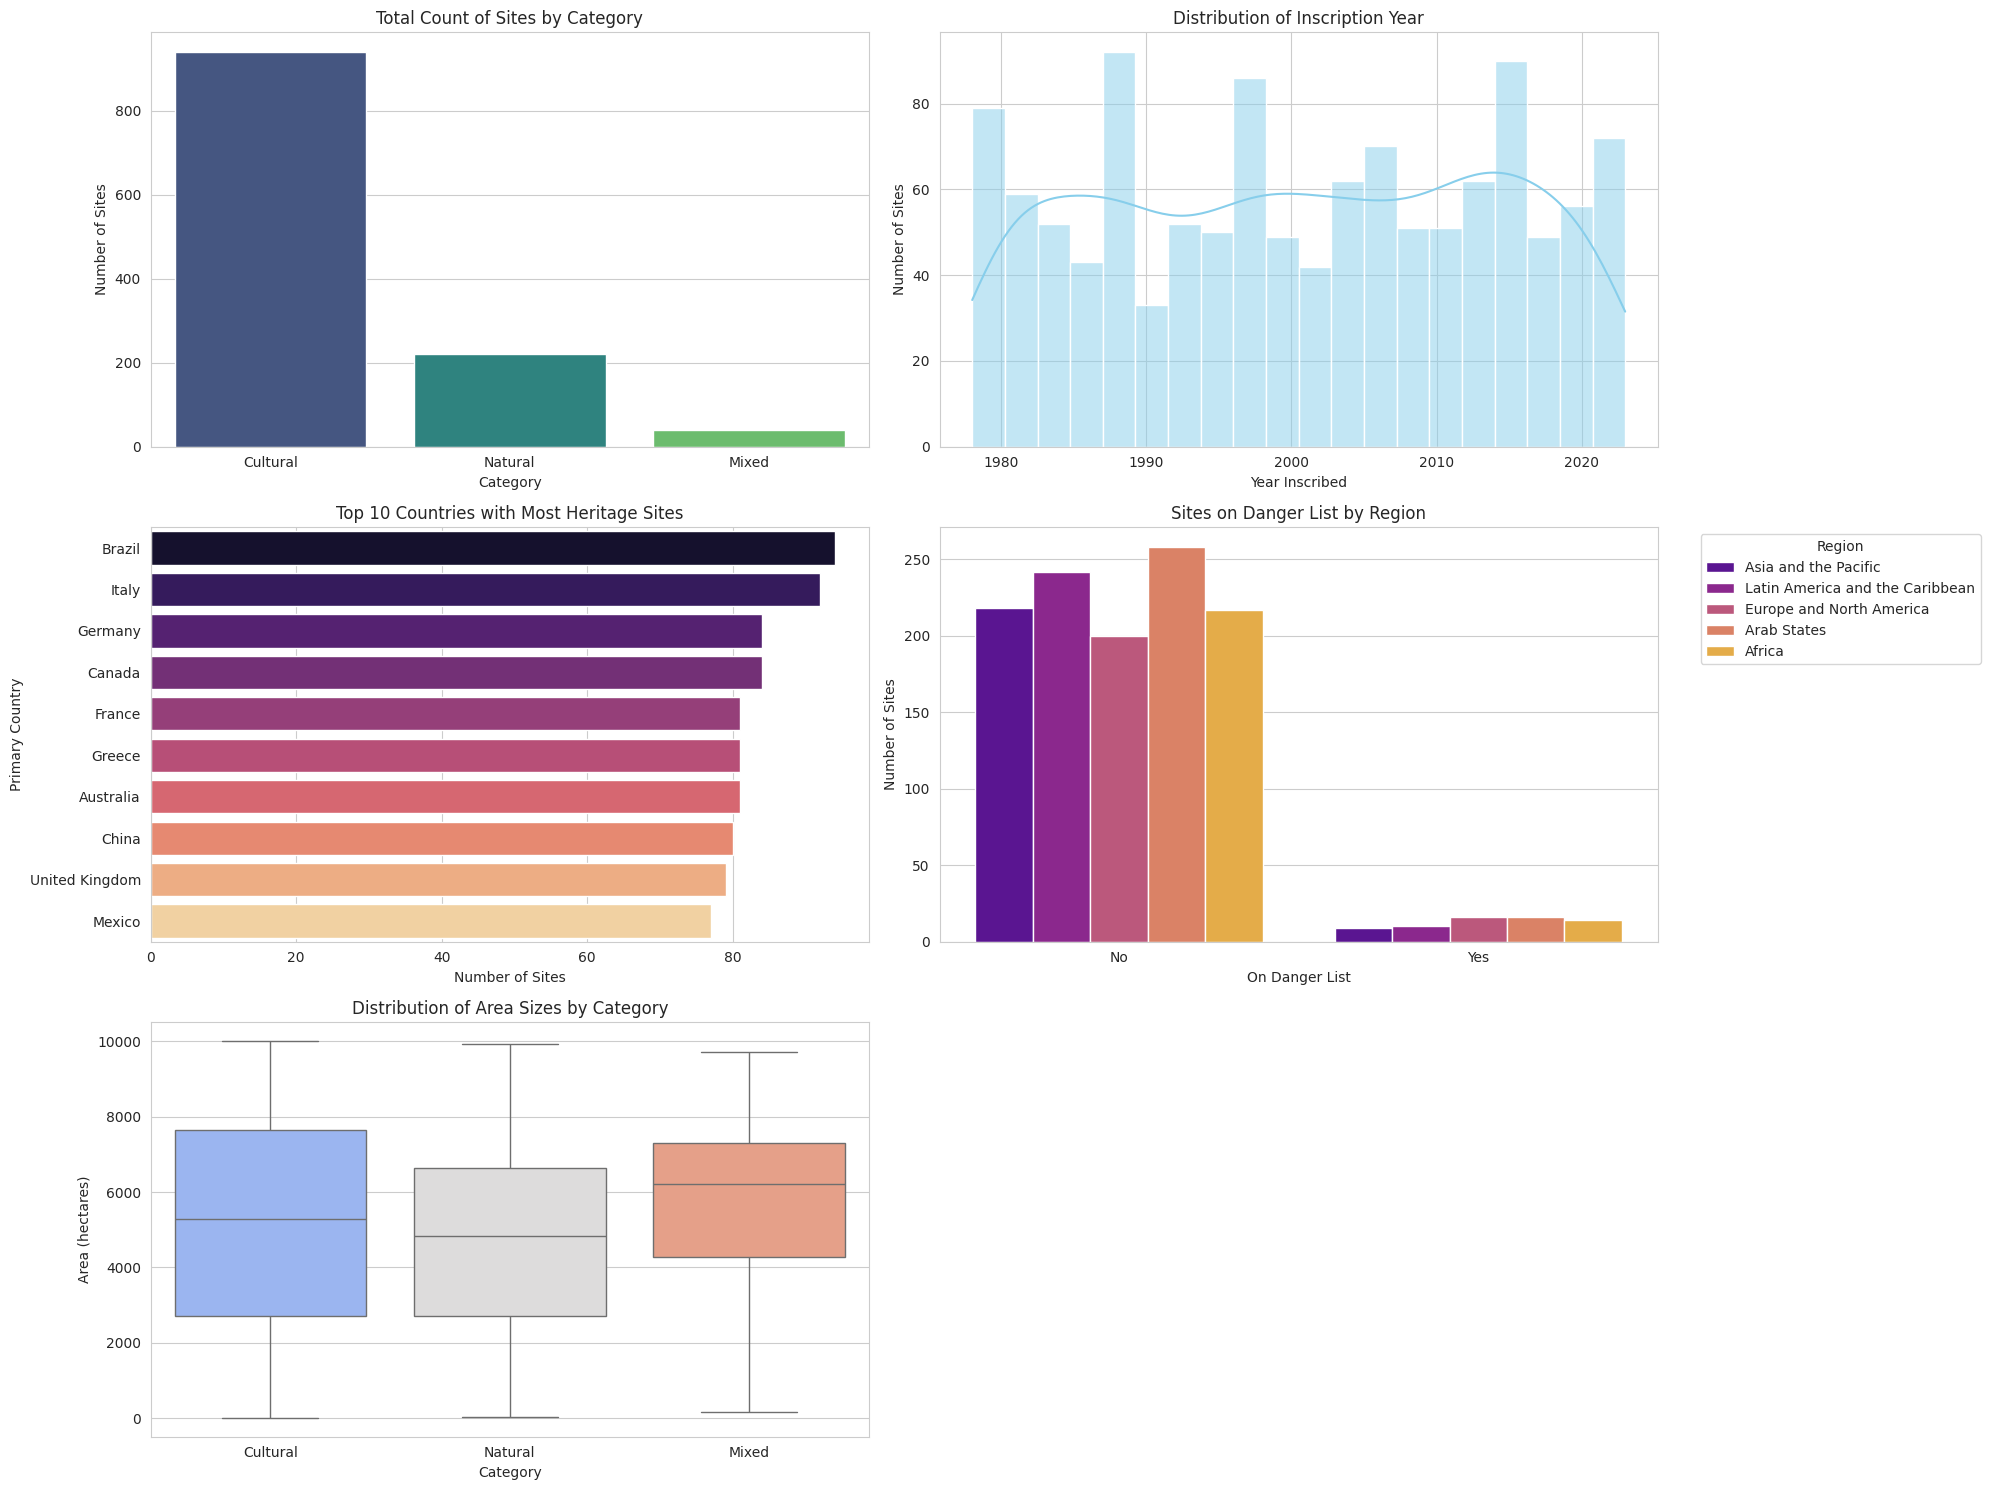

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

plt.figure(figsize=(20, 15))

# Bar Chart: Total count of sites by Category
plt.subplot(3, 2, 1) # 3 rows, 2 columns, 1st plot
sns.countplot(data=df_clean, x='Category', palette='viridis')
plt.title('Total Count of Sites by Category')
plt.xlabel('Category')
plt.ylabel('Number of Sites')

# Histogram: Sites added over time based on Year
plt.subplot(3, 2, 2) # 3 rows, 2 columns, 2nd plot
sns.histplot(data=df_clean, x='Year', bins=20, kde=True, color='skyblue')
plt.title('Distribution of Inscription Year')
plt.xlabel('Year Inscribed')
plt.ylabel('Number of Sites')

# Horizontal Bar Chart: Top 10 primary_country values
plt.subplot(3, 2, 3) # 3 rows, 2 columns, 3rd plot
top_countries = df_clean['primary_country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')
plt.title('Top 10 Countries with Most Heritage Sites')
plt.xlabel('Number of Sites')
plt.ylabel('Primary Country')

# Grouped Bar Chart: Sites on Danger list, grouped by Region
plt.subplot(3, 2, 4) # 3 rows, 2 columns, 4th plot
sns.countplot(data=df_clean, x='Danger', hue='Region', palette='plasma')
plt.title('Sites on Danger List by Region')
plt.xlabel('On Danger List')
plt.ylabel('Number of Sites')
plt.xticks(rotation=0)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')

# Box Plot: Distribution of Area sizes for each Category
plt.subplot(3, 2, 5) # 3 rows, 2 columns, 5th plot
sns.boxplot(data=df_clean, x='Category', y='Area', palette='coolwarm')
plt.title('Distribution of Area Sizes by Category')
plt.xlabel('Category')
plt.ylabel('Area (hectares)')

plt.tight_layout()
plt.show()

### Step 4: Interactive Map

In [ ]:
import plotly.express as px

# Create the interactive world map
fig = px.scatter_geo(
    df_clean,
    lat='Latitude',
    lon='Longitude',
    color='Category', # Color dots based on Category
    hover_name='Name', # Display site name on hover
    hover_data={'Year': True, 'Category': False, 'primary_country': True, 'Area': True}, # Include Year, country, and area in hover
    projection='natural earth', # Set map projection
    title='UNESCO World Heritage Sites Across the Globe',
    color_discrete_map={'Cultural': 'blue', 'Natural': 'green', 'Mixed': 'orange'}
)

fig.update_geos(showcoastlines=True, coastlinecolor="Black", showocean=True, oceancolor="LightBlue")
fig.update_layout(height=600, margin={"r":0,"t":50,"l":0,"b":0})
fig.show()